In [41]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
train_data = pd.read_csv('house/train.csv')
target,train_data = train_data['SalePrice'],train_data.drop(columns='SalePrice',axis=1)
test_data = pd.read_csv('house/test.csv')

In [42]:
train_data.shape,test_data.shape

((1460, 80), (1459, 80))

1. MSSubClass (类别型)：住宅类型（20种建筑分类）
2. MSZoning (类别型)：土地分区类型（8种 zoning 分类）
3. LotFrontage (数值型)：临街长度（英尺）
4. LotArea (数值型)：地块面积（平方英尺）
5. BldgType (类别型)：建筑类型（单户住宅/双户转换等）
6. HouseStyle (类别型)：房屋风格（单层/复式等8种）
7. GrLivArea (数值型)：地上居住面积
8. TotalBsmtSF (数值型)：地下室总面积
9. 1stFlrSF+2ntrain_datalrSF (数值型)：第一/二层面积
10. OverallQual (1-10)：整体材料与工艺质量等级
11. OverallCond (1-10)：房屋整体状况等级
12. ExterQual/ExterCond (Ex/Gd/TA/Fa/Po)：外部质量评估
13. KitchenQual (同上)：厨房质量等级
14. CentralAir (二分类)：是否有中央空调
15. Fireplaces (数值型)：壁炉数量
16. GarageCars+GarageArea (数值型)：车库容量与面积
17. PoolArea (数值型)：泳池面积
18. YearBuilt (数值型)：建造年份
19. YearRemodAdd (数值型)：改造年份
20. YrSold (数值型)：出售年份
21. Neighborhood (类别型)：25个社区位置
22. Condition1/2 (类别型)：周边设施情况（铁路/公路等）
23. SaleType (类别型)：交易类型（9种）
24. SaleCondition (类别型)：交易条件（正常/异常等6种）
25. SalePrice (数值型)：售价

In [43]:
# 预处理
# 用中位数填充缺失值
num_features = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
train_data[num_features] = train_data[num_features].fillna(train_data[num_features].median())

# 用None填充缺失值
cat_features = ['Alley','MasVnrType','BsmtQual','GarageType']
train_data[cat_features] = train_data[cat_features].fillna('None')
test_data[cat_features] = test_data[cat_features].fillna('None')

# 转化null的意义(不是缺失值，而是代表没有)
train_data['PoolQC'] = train_data['PoolQC'].fillna('None')
train_data['Fence'] = train_data['Fence'].fillna('None')
test_data['PoolQC'] = test_data['PoolQC'].fillna('None')
test_data['Fence'] = test_data['Fence'].fillna('None')

# 对一些具有等级含义的特征进行映射处理
qual_dict = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'NaN':0}
train_data['ExterQual'] = train_data['ExterQual'].map(qual_dict).fillna(0)
train_data['BsmtCond'] = train_data['BsmtCond'].map(qual_dict).fillna(0)
test_data['ExterQual'] = test_data['ExterQual'].map(qual_dict).fillna(0)
test_data['BsmtCond'] = test_data['BsmtCond'].map(qual_dict).fillna(0)

# 标准化处理
scaler = StandardScaler()
num_features = ['LotArea', 'TotalBsmtSF', 'GrLivArea']
train_data[num_features] = scaler.fit_transform(train_data[num_features])
test_data[num_features] = scaler.transform(test_data[num_features])

# 剩下的用独热编码处理
object_columns = train_data.select_dtypes(include='object').columns
train_data = pd.get_dummies(train_data, columns=object_columns)
test_data = pd.get_dummies(test_data, columns=object_columns)

# 专门对测试集的缺失值处理
test_data['LotFrontage'] = test_data['LotFrontage'].fillna(test_data['LotFrontage'].median())
test_data['MasVnrArea'] = test_data['MasVnrArea'].fillna(0)
for col in ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF']:
    test_data[col] = test_data[col].fillna(0)
for col in ['BsmtFullBath', 'BsmtHalfBath']:
    test_data[col] = test_data[col].fillna(0)
test_data['GarageYrBlt'] = test_data['GarageYrBlt'].fillna(0)
for col in ['GarageCars', 'GarageArea']:
    test_data[col] = test_data[col].fillna(0)

# 对齐训练集和测试集的特征
train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)
train_data = train_data.astype('float64')
test_data = test_data.astype('float64')

In [44]:
print(f"训练集维度: {train_data.shape}，测试集维度: {test_data.shape}")

训练集维度: (1460, 288)，测试集维度: (1459, 288)


In [45]:
missing_stats = train_data.isnull().sum()[train_data.isnull().sum() > 0]
print("存在缺失值的特征及数量:\n", missing_stats)

print("\n测试集缺失统计:")
print(test_data.isnull().sum()[test_data.isnull().sum() > 0])

存在缺失值的特征及数量:
 Series([], dtype: int64)

测试集缺失统计:
Series([], dtype: int64)


In [46]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)
# 损失函数
loss_fn = nn.MSELoss()

In [47]:
class MLP(nn.Module):
    def __init__(self,input_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        return self.model(x)
def rmsle_loss(y_hat, y_true):
    y_hat = torch.clamp(y_hat, min=1e-8)  # 确保预测值大于0
    y_true = torch.clamp(y_true, min=1e-8)
    y_hat_log = torch.log(y_hat)
    y_true_log = torch.log(y_true)
    return torch.sqrt(torch.mean((y_hat_log - y_true_log)**2))


Fold 1/5
 Training LinearRegression_Adam...
 Training LinearRegression_SGD...
 Training MLP_Adam...
 Training MLP_SGD...

Fold 2/5
 Training LinearRegression_Adam...
 Training LinearRegression_SGD...
 Training MLP_Adam...
 Training MLP_SGD...

Fold 3/5
 Training LinearRegression_Adam...
 Training LinearRegression_SGD...
 Training MLP_Adam...
 Training MLP_SGD...

Fold 4/5
 Training LinearRegression_Adam...
 Training LinearRegression_SGD...
 Training MLP_Adam...
 Training MLP_SGD...

Fold 5/5
 Training LinearRegression_Adam...
 Training LinearRegression_SGD...
 Training MLP_Adam...
 Training MLP_SGD...


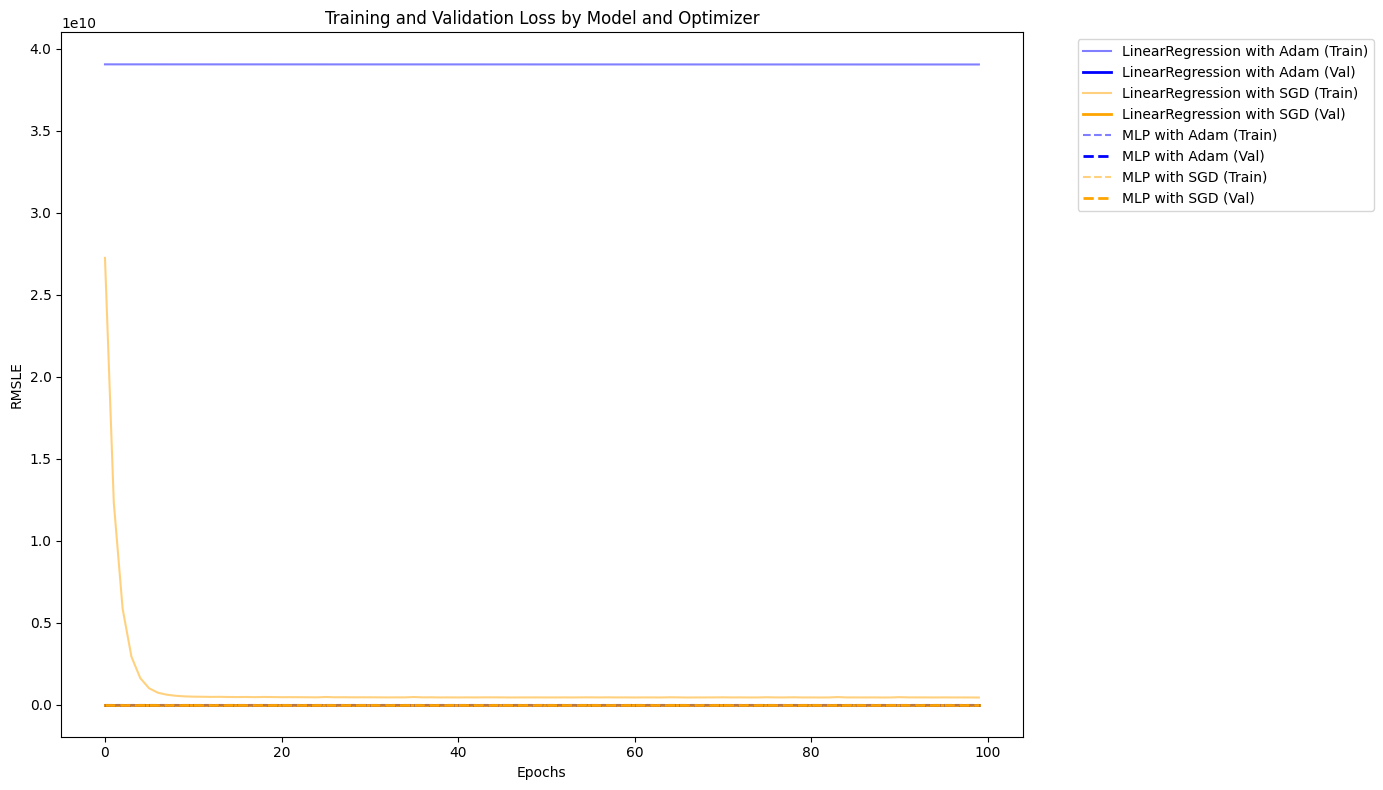

In [48]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
X = train_data
y = target
input_dim = X.shape[1]
output_dim = 1

# 训练参数
num_epochs = 100
learning_rates = {'Adam': 0.001, 'SGD': 0.01}
batch_size = 64

# 存储训练历史
histories = {
    'LinearRegression_Adam': {'train': [], 'val': []},
    'LinearRegression_SGD': {'train': [], 'val': []},
    'MLP_Adam': {'train': [], 'val': []},
    'MLP_SGD': {'train': [], 'val': []},
}

for fold, (train_idx, val_idx) in enumerate(kfold.split(X)):
    print(f"\nFold {fold+1}/5")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # 数据标准化
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # 转换为张量
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train.values).view(-1, 1)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.FloatTensor(y_val.values).view(-1, 1)

    # 创建DataLoader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # 训练所有模型组合
    for model_type in ['LinearRegression', 'MLP']:
        for optim_name in ['Adam', 'SGD']:
            key = f"{model_type}_{optim_name}"
            print(f" Training {key}...")

            # 初始化模型
            if model_type == 'LinearRegression':
                model = LinearRegressionModel(input_dim, output_dim)
                train_criterion = nn.MSELoss()  # 训练使用MSE
            else:
                model = MLP(input_dim, output_dim)
                train_criterion = rmsle_loss  # 训练使用RMSLE

            # 初始化优化器
            optimizer = getattr(torch.optim, optim_name)(
                model.parameters(), 
                lr=learning_rates[optim_name]
            )

            # 训练循环
            fold_train_loss = []
            fold_val_loss = []
            for epoch in range(num_epochs):
                # 训练
                model.train()
                epoch_train_loss = 0
                for X_batch, y_batch in train_loader:
                    optimizer.zero_grad()
                    y_pred = model(X_batch)
                    loss = train_criterion(y_pred, y_batch)
                    loss.backward()
                    optimizer.step()
                    epoch_train_loss += loss.item() * len(X_batch)
                
                # 验证
                model.eval()
                epoch_val_loss = 0
                with torch.no_grad():
                    for X_batch, y_batch in val_loader:
                        y_pred = model(X_batch)
                        loss = rmsle_loss(y_pred, y_batch)  # 统一使用RMSLE评估
                        epoch_val_loss += loss.item() * len(X_batch)
                
                # 记录损失
                epoch_train_loss = epoch_train_loss / len(train_loader.dataset)
                epoch_val_loss = epoch_val_loss / len(val_loader.dataset)
                fold_train_loss.append(epoch_train_loss)
                fold_val_loss.append(epoch_val_loss)

            # 保存当前fold结果
            histories[key]['train'].append(fold_train_loss)
            histories[key]['val'].append(fold_val_loss)

# 计算平均损失
plt.figure(figsize=(14, 8))
colors = {'Adam': 'blue', 'SGD': 'orange'}
linestyles = {'LinearRegression': '-', 'MLP': '--'}

for model_type in ['LinearRegression', 'MLP']:
    for optim_name in ['Adam', 'SGD']:
        key = f"{model_type}_{optim_name}"
        # 计算每个epoch的平均损失
        avg_train = np.mean(histories[key]['train'], axis=0)
        avg_val = np.mean(histories[key]['val'], axis=0)
        
        # 绘制曲线
        label = f"{model_type} with {optim_name}"
        plt.plot(avg_train, 
                 color=colors[optim_name], 
                 linestyle=linestyles[model_type],
                 alpha=0.5,
                 label=f'{label} (Train)')
        plt.plot(avg_val,
                 color=colors[optim_name],
                 linestyle=linestyles[model_type],
                 linewidth=2,
                 label=f'{label} (Val)')

plt.xlabel('Epochs')
plt.ylabel('RMSLE')
plt.title('Training and Validation Loss by Model and Optimizer')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()